In [1]:
from datetime import datetime

In [2]:
import arcgis
from arcgis.gis import GIS

gis = GIS("https://pythonapi.playground.esri.com/portal", "arcgis_python", "amazing_arcgis_123")
gis

GIS @ https://pythonapi.playground.esri.com/portal version:7.1

In [3]:
arcgis.env.verbose=True

In [4]:
rst_pcs1_zm=gis.content.search("title: rst_pcs1_zm")[0].layers[0]
rst_pcs1_zm.url

'https://pythonapi.playground.esri.com/server/rest/services/rst_pcs1_zm/ImageServer'

In [5]:
all_attr_renamed=gis.content.search("all_attr_renamed",item_type="Feature Layer Collection")[0].layers[0]
all_attr_renamed

<FeatureLayer url:"https://pythonapi.playground.esri.com/server/rest/services/Hosted/all_attr_renamed/FeatureServer/0">

Create Viewshed with distance values and context

In [6]:
aoi = {"xmin": 640707.799080802,"ymin": 4176384.86239104,"xmax": 948729.485705878,"ymax": 4378392.23564002,"spatialReference": {"wkt": "PROJCS[\"NAD_1983_UTM_Zone_11N\",GEOGCS[\"GCS_North_American_1983\",DATUM[\"D_North_American_1983\",SPHEROID[\"GRS_1980\",6378137.0,298.257222101]],PRIMEM[\"Greenwich\",0.0],UNIT[\"Degree\",0.0174532925199433]],PROJECTION[\"Transverse_Mercator\"],PARAMETER[\"False_Easting\",500000.0],PARAMETER[\"False_Northing\",0.0],PARAMETER[\"Central_Meridian\",-117.0],PARAMETER[\"Scale_Factor\",0.9996],PARAMETER[\"Latitude_Of_Origin\",0.0],UNIT[\"Meter\",1.0]],VERTCS[\"Unknown VCS\",VDATUM[\"Unknown\"],PARAMETER[\"Vertical_Shift\",0.0],PARAMETER[\"Direction\",1.0],UNIT[\"Meter\",1.0]]"}}

In [7]:
create_viewshed_1 = arcgis.raster.analytics.create_viewshed(input_elevation_surface=rst_pcs1_zm,
                                                            input_observer_features=all_attr_renamed,
                                                            optimize_for="ACCURACY",
                                                            maximum_viewing_distance={"distance":100000,"units":"meters"},
                                                            maximum_viewing_distance_field=None,
                                                            minimum_viewing_distance={"distance":20000,"units":"meters"},
                                                            minimum_viewing_distance_field=None,
                                                            viewing_distance_is_3d=None,
                                                            observers_elevation={"distance":2000,"units":"meters"},
                                                            observers_elevation_field=None,
                                                            observers_height={"distance":500,"units":"meters"},
                                                            observers_height_field=None,
                                                            target_height={"distance":500,"units":"meters"},
                                                            target_height_field=None,
                                                            above_ground_level_output_name="create_viewshed_agl_" + str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                                            output_name= "create_viewshed_" + str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                                            context={"extent":aoi},
                                                            folder="create_viewshed",
                                                            gis=gis)

Submitted.
Executing...
CreateViewshed GP Job: je5b4524b89ac4b718e7ae84f81c95fb3 finished successfully.


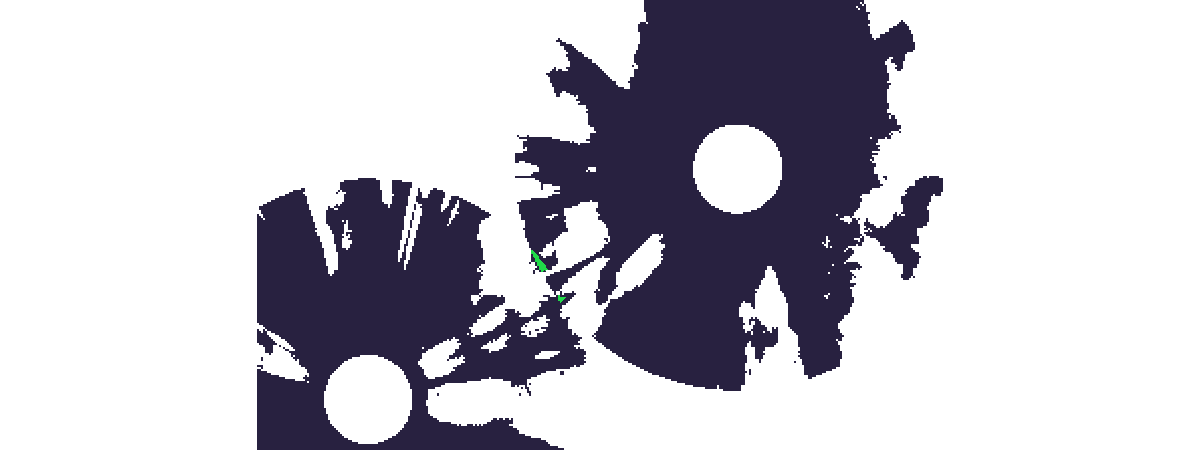

In [8]:
create_viewshed_1.output_raster.layers[0]

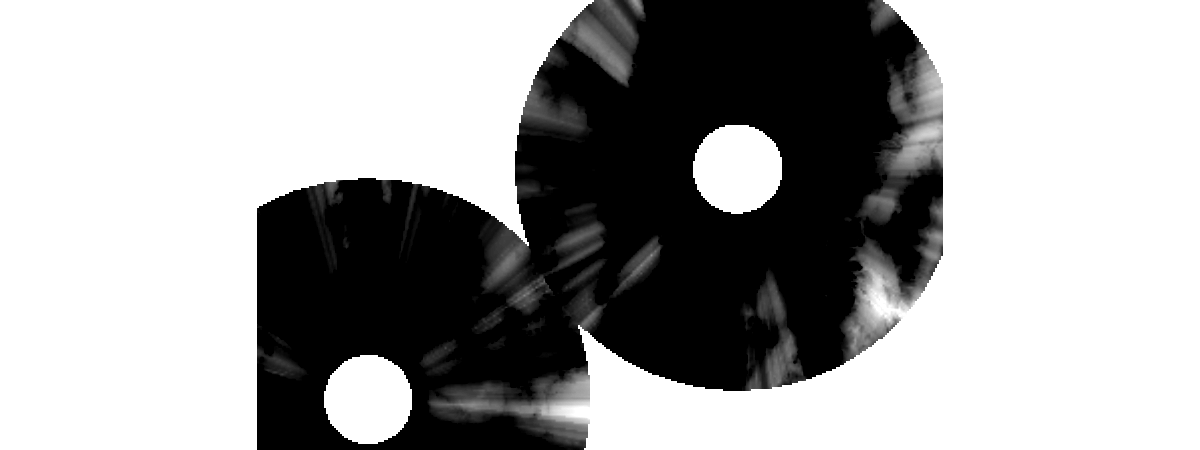

In [9]:
create_viewshed_1.output_above_ground_level_raster.layers[0]

Create Viewshed with distance field values and analysis_extent set

In [10]:
arcgis.env.analysis_extent = aoi
op_folder_name="create_viewshed" + str(datetime.now().strftime('%Y%m%d%H%M%S'))
create_viewshed_2 = arcgis.raster.analytics.create_viewshed(input_elevation_surface=rst_pcs1_zm,
                                                            input_observer_features=all_attr_renamed,
                                                            optimize_for="ACCURACY",
                                                            maximum_viewing_distance=None,
                                                            maximum_viewing_distance_field="dist2",
                                                            minimum_viewing_distance=None,
                                                            minimum_viewing_distance_field="dist1",
                                                            viewing_distance_is_3d=None,
                                                            observers_elevation=None,
                                                            observers_elevation_field="absheight",
                                                            observers_height=None,
                                                            observers_height_field="obshta",
                                                            target_height=None,
                                                            target_height_field="tghtb",
                                                            above_ground_level_output_name="create_viewshed_agl_" + str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                                            output_name= "create_viewshed_" + str(datetime.now().strftime('%Y%m%d%H%M%S')),
                                                            folder=op_folder_name,
                                                            future=True,
                                                            gis=gis)


Submitted.
Executing...
CreateViewshed GP Job: jaf8b7cca126b4becb38ad05ca62418cd finished successfully.


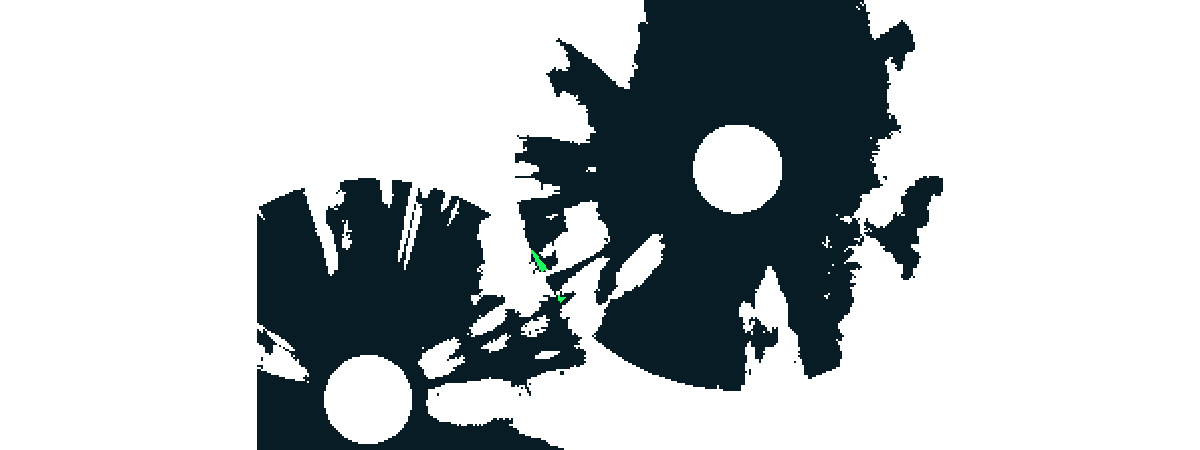

In [11]:
create_viewshed_2.result().output_raster.layers[0]

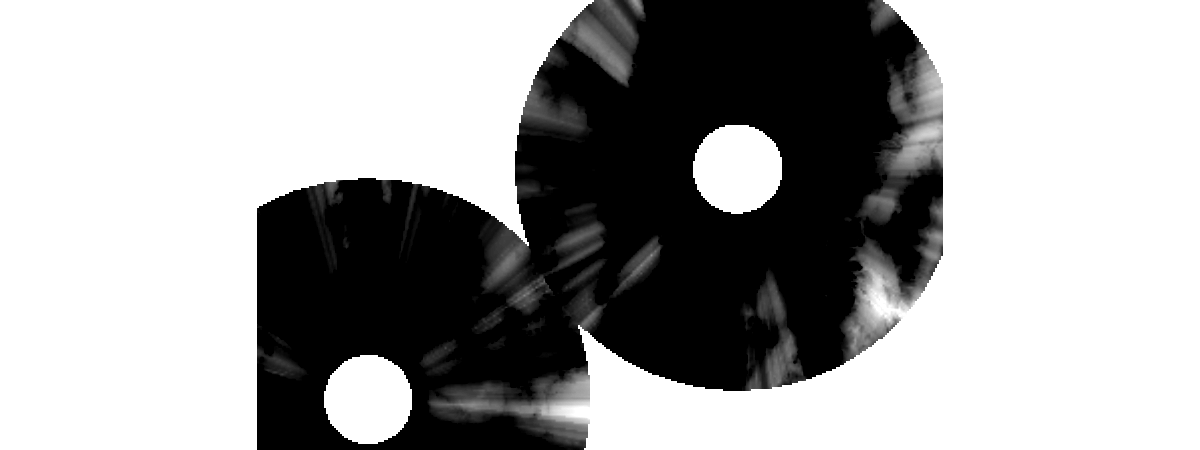

In [12]:
create_viewshed_2.result().output_above_ground_level_raster.layers[0]

<h4> Clean Up

In [13]:
create_viewshed_1.output_raster.delete()

True

In [14]:
create_viewshed_1.output_above_ground_level_raster.delete()

True

In [15]:
gis.content.delete_folder(op_folder_name)

True